In [1]:
#A Hidden Markov Model (HMM) is a probabilistic model where a sequence of observable variables are generated 
#by a sequence of hidden states. The important thing to note is the hidden states are not observed directly.

#The observed variables can be things like price while the hidden states can be a market regime.

#The transitions between hidden states assume to have the form of a Markov chain. 
#They can be specified by the start probability and a transition matrix.

#The emission probability of an observable variable can be any distribution based on the hidden state.

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from hmmlearn import hmm
import datetime as dt

In [8]:
end = dt.datetime.now()
start=dt.datetime(2018,3,31)

In [15]:
data = yf.download("SPY",start,end)
returns = np.log(data.Close / data.Close.shift(1))
range = (data.High - data.Low)
features = pd.concat([returns, range], axis=1).dropna()
features.columns = ["returns", "range"]

data_ = yf.download("^VIX",start,end)
returns_ = np.log(data_.Close / data_.Close.shift(1))
range_ = (data_.High - data_.Low)
features_ = pd.concat([returns_, range_], axis=1).dropna()
features_.columns = ["returns", "range"]

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [16]:
data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-04-02,262.549988,263.130005,254.669998,257.470001,233.061127,186286300
2018-04-03,258.869995,261.309998,256.839996,260.769989,236.048309,119956900
2018-04-04,256.750000,264.359985,256.600006,263.559998,238.573792,123715300
2018-04-05,265.549988,266.640015,264.320007,265.640015,240.456619,82652600
2018-04-06,263.420013,265.109985,258.000000,259.720001,235.097855,179521200


In [17]:
data_.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-04-02,21.070000,25.719999,20.440001,23.620001,23.620001,0
2018-04-03,23.030001,23.379999,20.920000,21.100000,21.100000,0
2018-04-04,21.680000,24.510000,19.860001,20.059999,20.059999,0
2018-04-05,19.760000,20.209999,18.570000,18.940001,18.940001,0
2018-04-06,20.330000,23.120001,18.600000,21.490000,21.490000,0


In [22]:
#Fit Markov Model

#SPX

model = hmm.GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
)
model.fit(features)


GaussianHMM(covariance_type='full', n_components=3, n_iter=1000)

In [23]:
#VIX
model_ = hmm.GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
)
model_.fit(features_)

GaussianHMM(covariance_type='full', n_components=3, n_iter=1000)

In [26]:
#The result is a histogram showing the number of daily states across the data.

<Axes: >

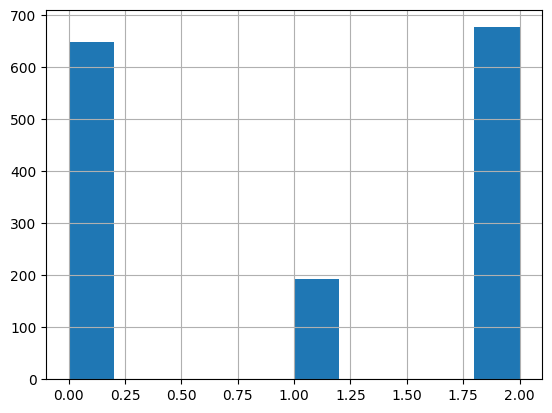

In [27]:
#SPX
states = pd.Series(model.predict(features), index=data.index[1:])
states.name = "stateSP"
states.hist()



<Axes: >

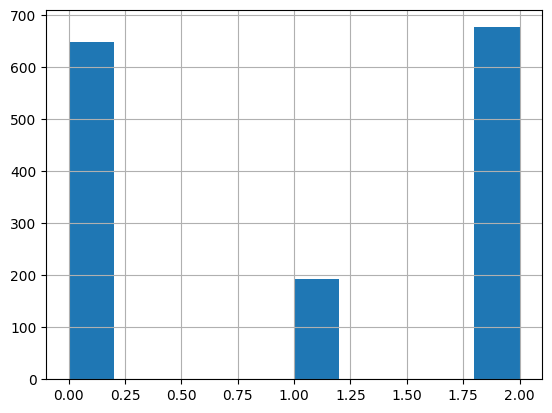

In [28]:
#VIX
states_ = pd.Series(model_.predict(features_), index=data.index[1:])
states_.name = "stateVIX"
states.hist()

<Axes: xlabel='Date'>

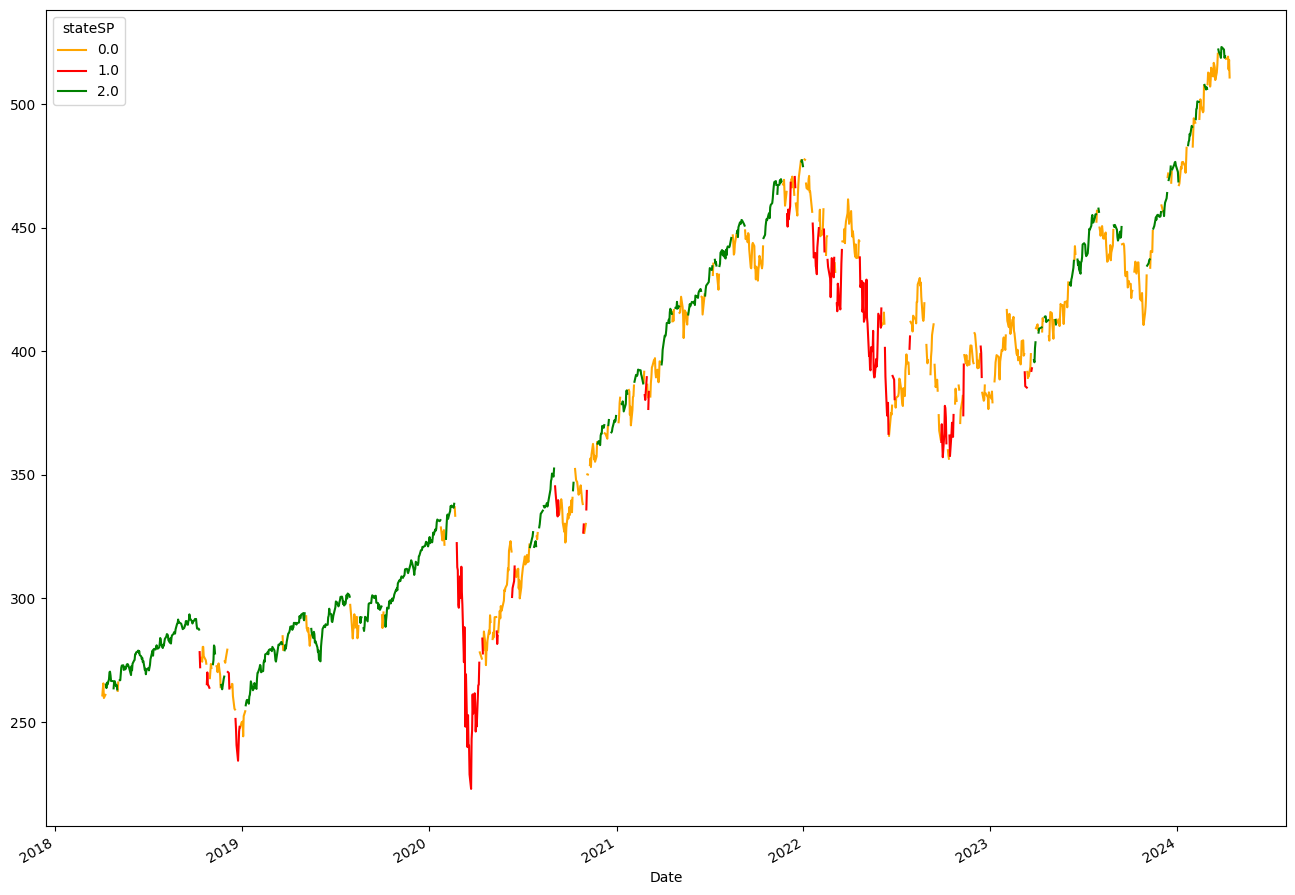

In [31]:
#Visualize the regimes

color_map = {
    0.0: "orange",
    1.0: "red",
    2.0: "green"
}
(
    pd.concat([data.Close, states], axis=1)
    .dropna()
    .set_index("stateSP", append=True)
    .Close
    .unstack("stateSP")
    .plot(color=color_map, figsize=[16, 12])
)

<Axes: xlabel='Date'>

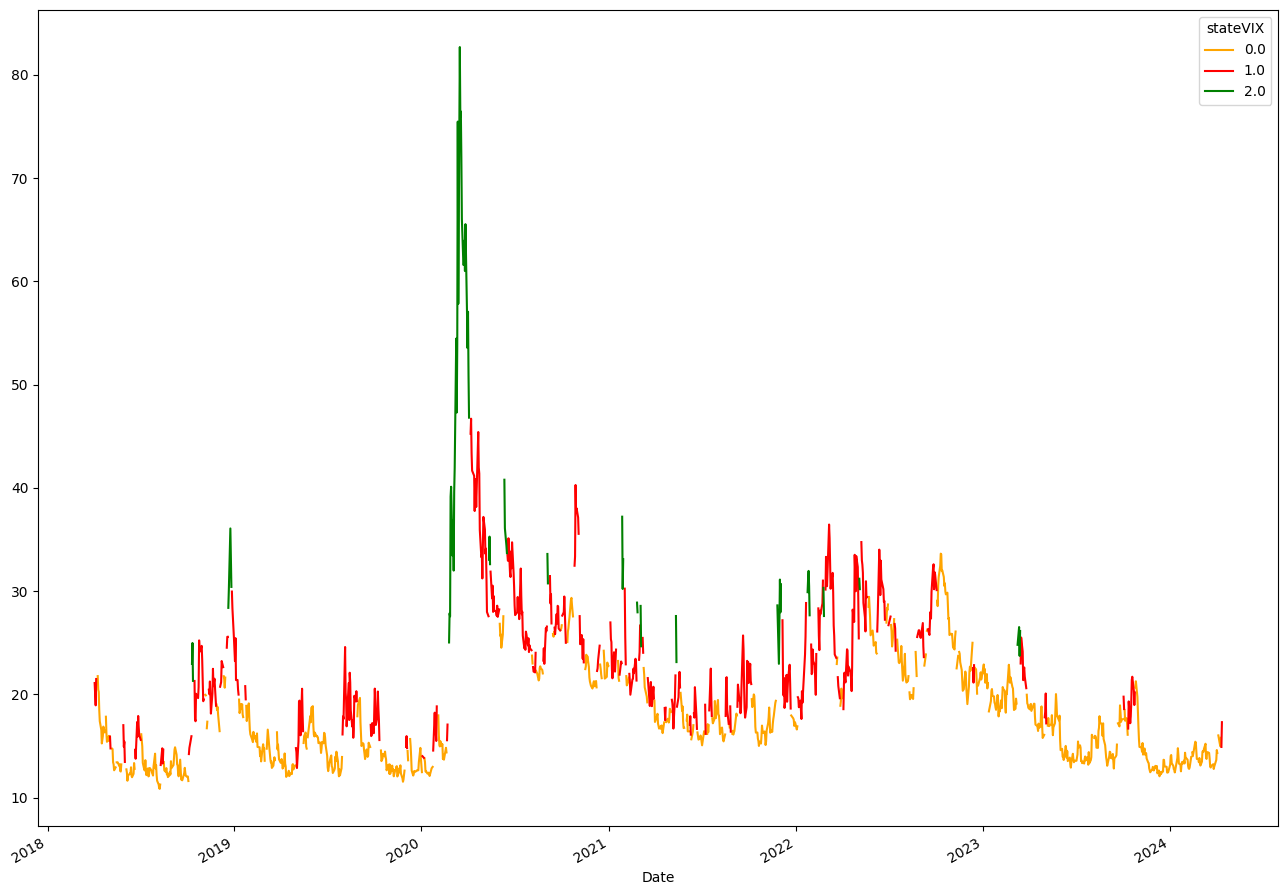

In [32]:
#Visualize the regimes

color_map = {
    0.0: "orange",
    1.0: "red",
    2.0: "green"
}
(
    pd.concat([data_.Close, states_], axis=1)
    .dropna()
    .set_index("stateVIX", append=True)
    .Close
    .unstack("stateVIX")
    .plot(color=color_map, figsize=[16, 12])
)